<a href="https://colab.research.google.com/github/MhiyaJ/My-GIS-Stuff/blob/main/solvedHappy2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
%%capture
#!pip install geopandas #==1.0.1
#!pip install mapclassify #sometimes have to install library which you get from https://pypi.org/

In [4]:
import os, zipfile #basics
import pandas as pd #data management
import matplotlib.pyplot as plt #vis

import geopandas as gpd #gis/maps: a sister of pandas; does the job;
#tho not as fancy-interactive as folium or leafmap https://geopandas.org/

import mapclassify #need for thematic map classification

import seaborn as sns

#will display all output not just last command
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from google.colab import files #to download from colab onto hd

#from google.colab import data_table
#data_table.enable_dataframe_formatter() #this enables spreadsheet view upon calling dataframe (without() )
from google.colab.data_table import DataTable
DataTable.max_columns = 250

In [5]:
#!python --version
gpd.__version__

'1.1.4'

**Hypothesis**: Limited access to affordable after-school programs contributes to increased social disengagement and delinquent behavior among students living in urban areas.

**Project Description:** Identifying the availability and accessibility of after school programs in low income areas and examining their relationship to youth social disengagement and delinquent behaviors.  

*Variables:* After school programs, economically disadvantaged youth population, delinquent/disengaged behavior, household income

Unified School Districts in NJ - includes and operates primary, secondary and high school as one district

Census data used to create boundaries for unified school districts.

NJ Office of GIS used Census data to establish unified school district boundaries in two areas, on and near military bases, were edited to reflect special arrangements made for students residing in base housing.

NJDOE used set of grades, based on financial responsibility, to assign the data for each child to exactly one school district, except for districts covering Joint Base McGuire-Dix-Lakehurst in Burlington County.

In [6]:
#NJ Office of GIS (Jan. 14, 2022), School Districts - Unified for NJ, 3424
#https://njogis-newjersey.opendata.arcgis.com/datasets/newjersey::school-districts-unified-for-nj-3424/about)
#unified school district shown in mp below was made with municipalities in mind
! wget -q -O nj-schools.zip https://github.com/MhiyaJ/My-GIS-Stuff/raw/refs/heads/main/School_Districts___Unified_7341673536716239500.zip

zip_ref = zipfile.ZipFile('nj-schools.zip', 'r'); zip_ref.extractall(); zip_ref.close()

njSch=gpd.read_file('School_Districts_Unified.shp') #labeled shapefile njSch

<Axes: >

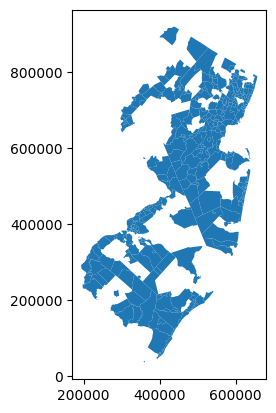

In [7]:
njSch.plot()

In [9]:
len(njSch)

339

In [10]:
njSch.dtypes #School District Headings

,0
NJDOE_ID_U,object
DIST_NAME,object
UNSDLEA,object
SD_TYPE,object
GEOID,object
geometry,geometry


In [11]:
DisXls=pd.read_excel ('https://github.com/MhiyaJ/My-GIS-Stuff/raw/refs/heads/main/Economically%20Disadvantage%20Youth%202024%20-%202025.xlsx', header = 3)

In [12]:
len(DisXls)

41

In [13]:
DisXls.dtypes

,0
CountyCode,int64
CountyName,object
DistrictCode,int64
DistrictName,object
SchoolYear,object
Female,object
Male,object
Non-Binary/Undesignated Gender,object
Economically Disadvantaged Students,object
Students with Disabilities,object


In [14]:
DisXls1=DisXls [['CountyName','DistrictName','Economically Disadvantaged Students']]
DisXls1.rename(columns={'DistrictName' : 'DIST_NAME'}, inplace=True)
DisXls1

/tmp/ipykernel_1205/1806286204.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DisXls1.rename(columns={'DistrictName' : 'DIST_NAME'}, inplace=True)


,CountyName,DIST_NAME,Economically Disadvantaged Students
0,Camden,Audubon Public School District,24.5%
1,Camden,Barrington School District,34.1%
2,Camden,Bellmawr Public School District,57.8%
3,Camden,Berlin Borough School District,25.2%
4,Camden,Berlin Township School District,53.3%
5,Camden,Black Horse Pike Regional School District,44.9%
6,Camden,Brooklawn Public School District,70.7%
7,Camden,Camden City School District,88.5%
8,Camden,Camden County Technical School District,56.1%
9,Camden,Cherry Hill School District,23.2%


In [15]:
njSch[['DIST_NAME','GEOID']]
DisXls1['c']=DisXls1.DIST_NAME.str.strip()
njSch['c']=njSch.DIST_NAME.str.strip()

,DIST_NAME,GEOID
0,Willingboro Public School District,3418000
1,South River Public School District,3415390
2,East Brunswick Township School District,3404110
3,Monroe Township School District,3410500
4,Dumont Public School District,3403990
...,...,...
334,Commercial Township School District,3403480
335,Maurice River Township School District,3409780
336,Lacey Township School District,3408100
337,Ocean Township School District,3412090


/tmp/ipykernel_1205/337144110.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DisXls1['c']=DisXls1.DIST_NAME.str.strip()


In [16]:
DisXls1[['DIST_NAME','Economically Disadvantaged Students']]

,DIST_NAME,Economically Disadvantaged Students
0,Audubon Public School District,24.5%
1,Barrington School District,34.1%
2,Bellmawr Public School District,57.8%
3,Berlin Borough School District,25.2%
4,Berlin Township School District,53.3%
5,Black Horse Pike Regional School District,44.9%
6,Brooklawn Public School District,70.7%
7,Camden City School District,88.5%
8,Camden County Technical School District,56.1%
9,Cherry Hill School District,23.2%


In [17]:
list(njSch.DIST_NAME.head(5))
list(DisXls1.DIST_NAME.head(5))

['Willingboro Public School District',
 'South River Public School District',
 'East Brunswick Township School District',
 'Monroe Township School District',
 'Dumont Public School District']

['Audubon Public School District',
 'Barrington School District',
 'Bellmawr Public School District',
 'Berlin Borough School District',
 'Berlin Township School District']

In [18]:
a1 = pd.merge(njSch, DisXls1, left_on='c', right_on='c', how='outer', indicator=True)
a1

,NJDOE_ID_U,DIST_NAME_x,UNSDLEA,SD_TYPE,GEOID,geometry,c,CountyName,DIST_NAME_y,Economically Disadvantaged Students,_merge
0,01-0010,Absecon Public Schools District,00660,U,3400660,"POLYGON ((503391.012 215174.719, 503092.48 211...",Absecon Public Schools District,NaN,NaN,NaN,left_only
1,41-0030,Allamuchy Township School District,00720,U,3400720,"POLYGON ((405096.281 772356.25, 406697.469 770...",Allamuchy Township School District,NaN,NaN,NaN,left_only
2,25-0050,Allenhurst School District,00780,U,3400780,"POLYGON ((633359.751 511841.852, 633367.748 51...",Allenhurst School District,NaN,NaN,NaN,left_only
3,33-0060,Alloway Twp School District,00810,U,3400810,"POLYGON ((270406.342 276106.935, 272736.652 27...",Alloway Twp School District,NaN,NaN,NaN,left_only
4,41-0070,Alpha Borough School District,00840,U,3400840,"POLYGON ((311826.54 670255.46, 311866.85 67014...",Alpha Borough School District,NaN,NaN,NaN,left_only
...,...,...,...,...,...,...,...,...,...,...,...
354,09-5840,Woodbine School District,18090,U,3418090,"POLYGON ((403963.313 153137.25, 416762.281 142...",Woodbine School District,NaN,NaN,NaN,left_only
355,23-5850,Woodbridge Township School District,18120,U,3418120,"POLYGON ((548930.697 641772.802, 550167.286 64...",Woodbridge Township School District,NaN,NaN,NaN,left_only
356,15-5860,Woodbury City Public School District,18150,U,3418150,"POLYGON ((311704.433 371407.465, 311619.079 37...",Woodbury City Public School District,NaN,NaN,NaN,left_only
357,07-5900,Woodlynne School District,18270,U,3418270,"POLYGON ((326156.607 396643.803, 326112.001 39...",Woodlynne School District,Camden,Woodlynne School District,80.6%,both


In [19]:
a1._merge.value_counts()

,count
_merge,
left_only,318
both,21
right_only,20
